In [206]:
import numpy as np
import healpy as hp
from matplotlib import pyplot as plt
import pysm3
import pysm3.units as u

import sys
sys.path.append('../')

from scripts.compute_decoupled_cl import compute_decoupled_cl
from scripts.apply_HILC import apply_HILC
from scripts.simulate_planck_maps import simulate_planck_maps
from scripts.cosine_smoothed_mask import cosine_smoothed_mask

%matplotlib inline

In [ ]:
nside=128
lmax=3*nside -1    
freqs = np.array([28.4,  44.1,  70.4,  100.0,  143.0,  217.0,  353.0])
n_freqs=len(freqs)
ells = np.arange(lmax + 1)
norm = (ells * (ells+ 1)) / (2 * np.pi)
nsims=10

In [4]:
mask2 = cosine_smoothed_mask(nside)
mask2= (mask2*(-1))+1

/tmp/ipykernel_455076/2218171100.py:4: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=382`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  input_cmb =np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat",skiprows=0, max_rows=382 ,usecols=(1))


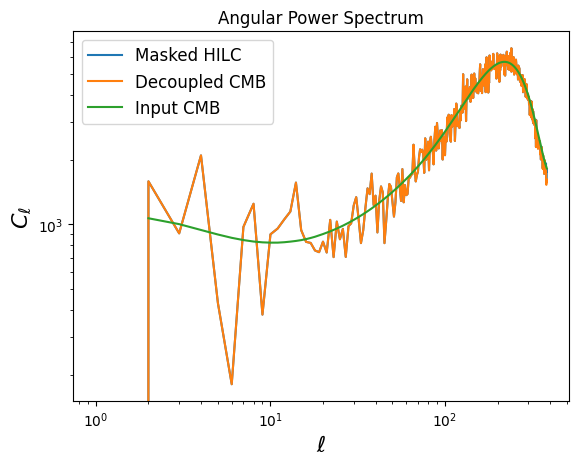

In [224]:
noise, dust, sync, ff, cmb = simulate_planck_maps(nside, freqs)
hilc= apply_HILC(cmb)
dec_cmb=compute_decoupled_cl(cmb, mask2, False, nside,lmax, n_freqs)
input_cmb =np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat",skiprows=0, max_rows=382 ,usecols=(1))

hilc_cmb= compute_decoupled_cl(hilc,mask2, True, nside, lmax, n_freqs)

plt.plot(ells, norm*hilc_cmb[:,0,0], label='Masked HILC')
plt.plot(ells, norm*dec_cmb[:,0,0], label='Decoupled CMB')
plt.plot(ells[2:], input_cmb, label='Input CMB')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")

plt.legend(fontsize=12)
plt.title("Angular Power Spectrum")
plt.show()

In [ ]:
def gen_sims(nsims: int) -> np.ndarray:
    
    """
    Generates simulated CMB maps using PySM3.
    
    Parameters:
        nsims (int): number of simulations to generate.

    Returns:
        cmb_map (np.ndarray): simulated cmb maps.
    """
    nside = 128
     
    #freq = 100 * u.GHz
    npix=hp.nside2npix(nside)
    freqs = np.array([28.4,  44.1,  70.4,  100.0,  143.0,  217.0,  353.0])
    cmb_map=np.zeros((nsims, n_freqs, npix), dtype=float)
    for i in range(nsims):
        
        #Dictionary containing the configuration of the
        #components of the sky model
        
        sky_config = {
            "c1":{
                "class":"CMBLensed",
                "cmb_spectra" : "pysm_2/camb_lenspotentialCls.dat",
                "cmb_seed" : i,
                "apply_delens": False,
                "delensing_ells": "pysm_2/delens_ells.txt"
            }
        
            
        }
        for nf, freq in enumerate(freqs):
            
            # Initialize the PySM sky
            sky = pysm3.Sky(nside=nside, component_config=sky_config)
            # Convert emissions to uK_CMB
            conversion = u.K_RJ.to(u.K_CMB, equivalencies=u.cmb_equivalencies(freq * u.GHz))

            cmb_map[i,nf,:]=sky.get_emission(freq * u.GHz)[0] * conversion
            
    return(cmb_map)

In [226]:
cmb=gen_sims(10)
print(cmb.shape)

(10, 7, 196608)


In [212]:
def true_cmb() -> np.ndarray:
    """
    Generates the true CMB power spectrum using PySM3.
    
    Returns:
        cl_cmb (np.ndarray): true CMB power spectrum.
    """
    
    cl_th = np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat",skiprows=0, max_rows=382 ,usecols=(1))

    return cl_th

In [227]:

cls_sims=[]
cmb_maps=gen_sims(10)
for i in range(nsims):
    print ("processing simulation %d" % i)
    # noise, dust, sync, ff,_= simulate_planck_maps(nside, freqs)
    map_out=apply_HILC(cmb_maps[i,:,:]) #+noise+dust+sync+ff
    cl_out=compute_decoupled_cl(map_out, mask2, True, nside, lmax, n_freqs)
    cls_sims.append(cl_out)
cls_sims=np.array(cls_sims)

processing simulation 0
processing simulation 1
processing simulation 2
processing simulation 3
processing simulation 4
processing simulation 5
processing simulation 6
processing simulation 7
processing simulation 8
processing simulation 9


In [228]:
print(cls_sims.shape)

(10, 384, 7, 7)


In [229]:
Cl_cmb = true_cmb()
print(Cl_cmb.shape)

(382,)


/tmp/ipykernel_455076/3090107687.py:9: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=382`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  cl_th = np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat",skiprows=0, max_rows=382 ,usecols=(1))


In [230]:
cls_mean = np.mean(cls_sims, axis=0)  # Mean recovered Cl
cls_std = np.std(cls_sims, axis=0)  # Standard deviation (scatter)
cls_error = cls_std / np.sqrt(nsims)  # Error in mean estimate

bias = (cls_mean[2:,0,0] - Cl_cmb)/Cl_cmb  # Difference between recovered and input Cl

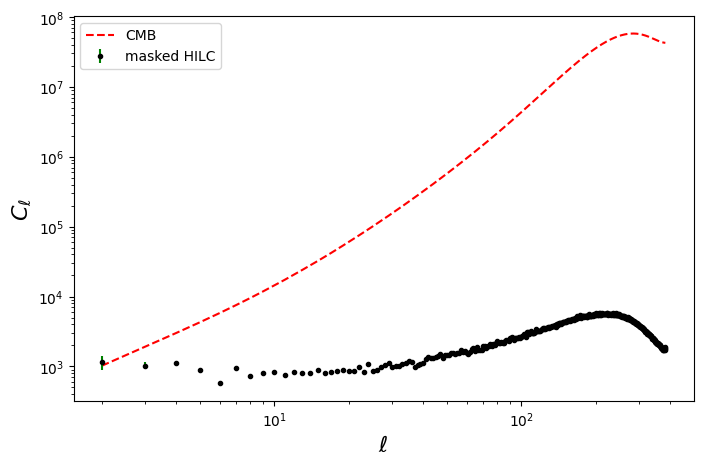

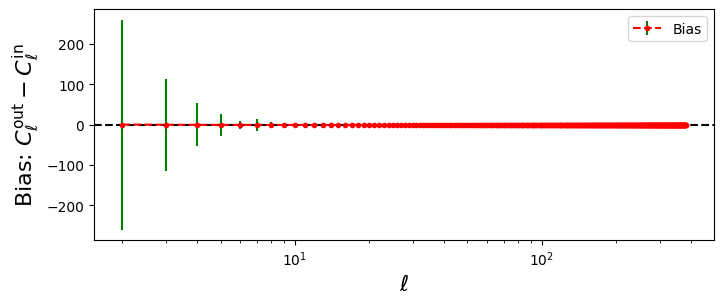

In [238]:

fig, ax = plt.subplots(figsize=(8, 5))

# Plot the input and recovered power spectra
ax.plot(ells[2:], norm[2:]*Cl_cmb, 'r--', label='CMB')
ax.errorbar(ells[2:], norm[2:]*cls_mean[2:,0,0], yerr=cls_error[2:,0,0],ecolor='g', fmt='k.', label='masked HILC')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$\ell$', fontsize=16)
ax.set_ylabel(r'$C_\ell$', fontsize=16)
ax.legend()
# ax.set_ylim([1e-3, 1e4])


# Bias plot
fig, ax2 = plt.subplots(figsize=(8, 3))
ax2.errorbar(ells[2:], bias, yerr=cls_error[2:,0,0], ecolor='g',fmt='r.--', label='Bias')
ax2.axhline(0, color='k', linestyle='--')
ax2.set_xlabel(r'$\ell$', fontsize=16)
ax2.set_ylabel(r'Bias: $C_\ell^{\text{out}} - C_\ell^{\text{in}}$', fontsize=16)
ax2.set_xscale('log')
# ax2.set_ylim(-5,5)
ax2.legend()

plt.show()

In [247]:
for i in range(10):  # For TT, EE, BB
   
    print(f"ℓ={i}: Simulated Cl: {cls_sims[0,i,0,0]}, Theoretical Cl: {Cl_cmb[i]}")


ℓ=0: Simulated Cl: -27.69014842785646, Theoretical Cl: 1067.8
ℓ=1: Simulated Cl: -12.362405155772063, Theoretical Cl: 1002.9
ℓ=2: Simulated Cl: 1465.4640357650724, Theoretical Cl: 942.74
ℓ=3: Simulated Cl: 1443.5715098901974, Theoretical Cl: 897.73
ℓ=4: Simulated Cl: 245.74062429034564, Theoretical Cl: 866.45
ℓ=5: Simulated Cl: 372.2500078522862, Theoretical Cl: 845.89
ℓ=6: Simulated Cl: 133.6609855406415, Theoretical Cl: 832.87
ℓ=7: Simulated Cl: 52.80850525992285, Theoretical Cl: 825.76
ℓ=8: Simulated Cl: 32.115387567687904, Theoretical Cl: 823.0
ℓ=9: Simulated Cl: 54.38417504977798, Theoretical Cl: 823.13
